## Generalisation Validation

This notebook tests whether the main findings from Notebook 3 generalise beyond the JAMK ICT dataset used for the primary evaluation. LaBSE, identified as the strongest model, is applied to a separate dataset of bilingual course description pairs from JAMK's Business Information Technology (BIT) degree programme. The BIT dataset was not used at any stage of model selection, threshold optimisation, or evaluation in Notebooks 1 to 3, making it a genuinely independent test of generalisation.

The evaluation separates two distinct questions that are often conflated. The first is whether LaBSE continues to discriminate well on a new domain (model-generalisation). The second is whether the threshold calibrated on ICT transfers to BIT without retuning (threshold-transfer). Both are reported side by side so the two can be assessed independently.

Two methodological details matter for the fairness of the transfer test. First, each BIT configuration is evaluated against the ICT threshold from the same configuration, not against a single ICT-wide threshold. Score distributions shift with text composition, so fair transfer requires matched configurations. Second, the BIT text-length and truncation profile is checked before evaluation, because BIT texts that truncate differently from ICT texts could introduce a confound that looks like domain shift but is really tokenizer behaviour.

Uncertainty is reported in two ways. Bootstrap 95 percent confidence intervals are attached to the Part A transferred-threshold F1 values on BIT. The Part B cross-validated F1 values on BIT are reported as mean and standard deviation across five folds. These are different uncertainty measures and are labelled as such in the result tables.

### Imports and Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from transformers import logging as hf_logging

import unicodedata
import re

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sentence_transformers")
hf_logging.set_verbosity_error()

print(f"Python               : {sys.version.split()[0]}")
print(f"torch                : {torch.__version__}")
print(f"transformers         : {version('transformers')}")
print(f"sentence-transformers: {version('sentence-transformers')}")
print(f"numpy                : {np.__version__}")
print(f"pandas               : {pd.__version__}")
print(f"sklearn              : {version('scikit-learn')}")
print(f"CUDA available       : {torch.cuda.is_available()}")

Python               : 3.10.20
torch                : 2.12.0.dev20260408+cu128
transformers         : 5.4.0
sentence-transformers: 5.3.0
numpy                : 2.2.6
pandas               : 2.3.3
sklearn              : 1.7.2
CUDA available       : True


### Project Paths

All paths are derived from the notebook's working directory. The BIT dataset lives in `data/raw/`, the ICT-based results from Notebook 3 live in `data/results/`, and outputs from this notebook are written to the same `data/results/` and `figures/main/` directories.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
RESULTS_DIR = DATA_DIR / "results"
SUMMARY_DIR = RESULTS_DIR / "summary_tables"
VALIDATION_DIR = RESULTS_DIR / "validation"
FIGURES_DIR = PROJECT_ROOT / "figures" / "main"

VALIDATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

bit_data_path = RAW_DIR / "verified_final_dataset_BIT.csv"

### Loading the BIT Dataset

The BIT dataset is loaded and passed through the same cleaning pipeline used in Notebook 1 so that any performance difference observed on BIT reflects genuine generalisation rather than preprocessing inconsistency. Integrity checks are run before any processing: labels must be binary, both classes must be present, and the Finnish columns must contain markedly more Finnish-specific characters than the English columns, catching column mislabelling silently.

In [3]:
bit_df = pd.read_csv(bit_data_path)

print(f"BIT dataset loaded: {bit_df.shape}")
print(f"Columns           : {bit_df.columns.tolist()}")
print(f"\nLabel distribution:\n{bit_df['similarity_label'].value_counts()}")

# Integrity checks
assert bit_df['similarity_label'].isin([0, 1]).all(), (
    "BIT similarity_label contains values outside {0, 1}"
)
assert set(bit_df['similarity_label'].unique()) == {0, 1}, (
    "BIT similarity_label missing one of the two classes"
)
if 'course_id' in bit_df.columns:
    assert bit_df['course_id'].is_unique, "Duplicate course_id values in BIT"

def fi_char_density(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    return sum(1 for c in text.lower() if c in 'äö') / len(text)

fi_density_fi = bit_df['outcomes_fi'].apply(fi_char_density).mean()
fi_density_en = bit_df['outcomes_en'].apply(fi_char_density).mean()
assert fi_density_fi > 5 * max(fi_density_en, 1e-6), (
    "BIT language sanity check failed"
)

print(f"\nmean ä/ö density (outcomes_fi): {fi_density_fi:.4f}")
print(f"mean ä/ö density (outcomes_en): {fi_density_en:.4f}")
print("All integrity checks passed.")

BIT dataset loaded: (72, 16)
Columns           : ['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'assessment_valid', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty']

Label distribution:
similarity_label
1    36
0    36
Name: count, dtype: int64

mean ä/ö density (outcomes_fi): 0.0386
mean ä/ö density (outcomes_en): 0.0000
All integrity checks passed.


### Cleaning and Building Configurations

The same cleaning function used in Notebook 1 is applied here: NFC Unicode normalization, removal of bullet-point characters and zero-width artifacts, and whitespace collapse. Three raw-text configurations are built, mirroring configurations 1, 2, and 3 from the main pipeline. Lemmatized configurations are not built because Notebook 3 showed that lemmatization produces no consistent benefit on LaBSE.

In [4]:
BULLET_CLASS = r'[\u2022\u2023\u25E6\u2043\u2219]'
INVISIBLE_CLASS = r'[\u200B\u200C\u200D\u00AD\uFEFF]'

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(BULLET_CLASS, '', text)
    text = re.sub(INVISIBLE_CLASS, '', text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_columns = [
    'outcomes_fi', 'outcomes_en',
    'contents_fi', 'contents_en',
    'assessment_fi', 'assessment_en',
]
for col in text_columns:
    bit_df[col] = bit_df[col].apply(clean_text)

bit_df['config_1_fi'] = bit_df['outcomes_fi']
bit_df['config_1_en'] = bit_df['outcomes_en']
bit_df['config_2_fi'] = bit_df['outcomes_fi'] + ' ' + bit_df['contents_fi']
bit_df['config_2_en'] = bit_df['outcomes_en'] + ' ' + bit_df['contents_en']
bit_df['config_3_fi'] = bit_df['outcomes_fi'] + ' ' + bit_df['contents_fi'] + ' ' + bit_df['assessment_fi']
bit_df['config_3_en'] = bit_df['outcomes_en'] + ' ' + bit_df['contents_en'] + ' ' + bit_df['assessment_en']

bit_config_cols = [f'config_{i}_{lang}' for i in (1, 2, 3) for lang in ('fi', 'en')]

# Verify no empty cells and no standalone nan tokens
for col in bit_config_cols:
    empty = int((bit_df[col].str.strip() == '').sum())
    nan_tok = int(bit_df[col].astype(str).apply(
        lambda x: bool(re.search(r'\bnan\b', x))
    ).sum())
    assert empty == 0, f"{col} has {empty} empty cells"
    assert nan_tok == 0, f"{col} has {nan_tok} standalone 'nan' tokens"

# Row count per class after cleaning
print(f"Post-cleaning class counts: {bit_df['similarity_label'].value_counts().to_dict()}")

sample = bit_df[bit_df['similarity_label'] == 1].iloc[0]
print(f"\nSample BIT pair (label=1):")
print(f"  Finnish outcomes: {sample['outcomes_fi'][:200]}")
print(f"  English outcomes: {sample['outcomes_en'][:200]}")

Post-cleaning class counts: {1: 36, 0: 36}

Sample BIT pair (label=1):
  Finnish outcomes: Kurssin tavoite:UX-suunnittelun kurssilla opit perusperiaatteet käyttäjäkokemuksesta ja ihmiskeskeisestä suunnittelusta peleissä. Ymmärrät peruskäsitteet ja -käytännöt liittyen käytettävyyteen, käyttä
  English outcomes: The object of the course: In the UX Design course you will learn the basic principles of user experience and human centered design in games. You will understand the basic terminology and conventions r


### BIT Token Length and Truncation Profile

Before any evaluation, the BIT configurations are passed through the LaBSE tokenizer so that token-length statistics and truncation incidence can be compared against the ICT profile recorded in Notebook 2. This check exists because if BIT texts truncate at a meaningfully different rate than ICT texts (in either direction), any observed F1 difference between the two datasets could partly reflect truncation behaviour rather than genuine domain shift.

The table below reports mean tokens, median tokens, maximum untruncated tokens, and percentage of texts exceeding 512 tokens, for all three BIT raw configurations in both languages. Large truncation gaps between BIT and ICT should be flagged in the limitations discussion.

In [5]:
labse_tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/LaBSE')

MAX_SEQ_LEN = 512

bit_trunc_rows = []
for cfg in (1, 2, 3):
    for lang in ('fi', 'en'):
        col = f'config_{cfg}_{lang}'
        token_lens = np.array([
            len(labse_tokenizer.encode(t, add_special_tokens=True, truncation=False))
            for t in bit_df[col]
        ])
        bit_trunc_rows.append({
            'config'                : cfg,
            'language'              : lang,
            'n_texts'               : len(token_lens),
            'mean_tokens'           : float(token_lens.mean()),
            'median_tokens'         : float(np.median(token_lens)),
            'max_tokens_untruncated': int(token_lens.max()),
            'n_truncated'           : int((token_lens > MAX_SEQ_LEN).sum()),
            'pct_truncated'         : float(100 * (token_lens > MAX_SEQ_LEN).mean()),
        })

bit_trunc_df = pd.DataFrame(bit_trunc_rows).round(
    {'mean_tokens': 1, 'median_tokens': 1, 'pct_truncated': 2}
)

bit_trunc_df.to_csv(VALIDATION_DIR / 'bit_truncation_report.csv', index=False)

print("BIT token length and truncation (LaBSE tokenizer):")
print(bit_trunc_df.to_string(index=False))

# Compare against ICT truncation report from Notebook 2 if available
ict_trunc_path = DATA_DIR / "processed" / "truncation_report.csv"
if ict_trunc_path.exists():
    ict_trunc = pd.read_csv(ict_trunc_path)
    ict_labse = ict_trunc[ict_trunc['model'] == 'labse']
    ict_labse_raw = ict_labse[ict_labse['config'].isin([1, 2, 3])]
    print("\nICT reference (from Notebook 2, LaBSE raw configs):")
    print(ict_labse_raw[['config', 'language', 'mean_tokens',
                         'pct_truncated']].to_string(index=False))
else:
    print("\nICT truncation report not found; BIT-vs-ICT comparison skipped.")

BIT token length and truncation (LaBSE tokenizer):
 config language  n_texts  mean_tokens  median_tokens  max_tokens_untruncated  n_truncated  pct_truncated
      1       fi       72        315.4          320.0                     678            2           2.78
      1       en       72        264.1          267.5                     778            1           1.39
      2       fi       72        408.5          401.5                     871           11          15.28
      2       en       72        338.2          347.5                     942            1           1.39
      3       fi       72        748.8          716.5                    1644           60          83.33
      3       en       72        610.3          572.0                    1599           47          65.28

ICT reference (from Notebook 2, LaBSE raw configs):
 config language  mean_tokens  pct_truncated
      1       fi        187.9           0.00
      1       en        150.3           0.00
      2       fi   

### Loading ICT Reference Results and Per-Configuration Thresholds

The ICT-based F1 values and the per-configuration CV thresholds are loaded from the CSV files produced by Notebook 3. Each BIT configuration will receive the ICT threshold from the matching configuration for the transfer test, rather than a single ICT-wide threshold. This is the fair design for a transfer test: score distributions shift with text composition, and a threshold selected on short texts would not necessarily be appropriate for long texts even on the original dataset.

The mean cross-validation threshold is used rather than the in-sample best threshold, because the CV mean is already a held-out estimate and is therefore the more honest choice for transfer.

In [6]:
ict_summary = pd.read_csv(SUMMARY_DIR / "full_evaluation_summary.csv")
ict_cv = pd.read_csv(SUMMARY_DIR / "cv_5fold_results.csv")

labse_summary = ict_summary[ict_summary['model'] == 'labse'].copy()
labse_cv = ict_cv[ict_cv['model'] == 'labse'].copy()

# Build a mapping from config-number -> (config name, transfer threshold, ICT references)
config_names = {
    1: 'Outcomes (Raw)',
    2: 'Outcomes + Contents (Raw)',
    3: 'Outcomes + Contents + Assessment (Raw)',
}

ict_reference = {}
for cfg_num, cfg_name in config_names.items():
    summ_row = labse_summary[labse_summary['config'] == cfg_name].iloc[0]
    cv_row = labse_cv[labse_cv['config'] == cfg_name].iloc[0]
    transfer_t = round(float(cv_row['threshold_mean']), 2)
    ict_reference[cfg_num] = {
        'config'               : cfg_name,
        'transfer_threshold'   : transfer_t,
        'ict_insample_threshold': float(summ_row['best_threshold']),
        'ict_cv_threshold_mean' : float(cv_row['threshold_mean']),
        'ict_cv_threshold_std'  : float(cv_row['threshold_std']),
        'ict_f1_insample'       : float(summ_row['f1']),
        'ict_f1_ci_low'         : float(summ_row['f1_ci_low']),
        'ict_f1_ci_high'        : float(summ_row['f1_ci_high']),
        'ict_f1_cv_mean'        : float(cv_row['cv_f1_mean']),
        'ict_f1_cv_std'         : float(cv_row['cv_f1_std']),
    }

print("Per-configuration transfer thresholds (loaded from ICT CV results):\n")
for cfg_num, ref in ict_reference.items():
    print(f"Config {cfg_num} ({ref['config']}):")
    print(f"  In-sample threshold : {ref['ict_insample_threshold']:.2f}")
    print(f"  CV mean threshold   : {ref['ict_cv_threshold_mean']:.2f} ± "
          f"{ref['ict_cv_threshold_std']:.2f}")
    print(f"  -> Transfer threshold: {ref['transfer_threshold']:.2f}")
    print(f"  ICT CV F1 (reference): {ref['ict_f1_cv_mean']:.3f} ± "
          f"{ref['ict_f1_cv_std']:.3f}")
    print()

Per-configuration transfer thresholds (loaded from ICT CV results):

Config 1 (Outcomes (Raw)):
  In-sample threshold : 0.87
  CV mean threshold   : 0.88 ± 0.01
  -> Transfer threshold: 0.88
  ICT CV F1 (reference): 0.968 ± 0.022

Config 2 (Outcomes + Contents (Raw)):
  In-sample threshold : 0.88
  CV mean threshold   : 0.88 ± 0.01
  -> Transfer threshold: 0.88
  ICT CV F1 (reference): 0.969 ± 0.043

Config 3 (Outcomes + Contents + Assessment (Raw)):
  In-sample threshold : 0.84
  CV mean threshold   : 0.84 ± 0.00
  -> Transfer threshold: 0.84
  ICT CV F1 (reference): 0.970 ± 0.030



### Generating LaBSE Embeddings for the BIT Dataset

LaBSE is loaded with `max_seq_length = 512` matching the configuration used in Notebook 2. Each produced embedding array is verified to have the expected shape and unit L2 norm as an immediate assertion, matching the sanity-check discipline used in Notebooks 2, 3, and 5.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))
model.max_seq_length = MAX_SEQ_LEN
print(f"Loaded LaBSE. max_seq_length = {model.max_seq_length}")

def l2_normalize(embeddings):
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / np.clip(norms, a_min=1e-10, a_max=None)

bit_embeddings = {}
configs = [1, 2, 3]

for config_num in configs:
    fi_texts = bit_df[f'config_{config_num}_fi'].tolist()
    en_texts = bit_df[f'config_{config_num}_en'].tolist()

    fi_emb = l2_normalize(model.encode(
        fi_texts, batch_size=32, show_progress_bar=False, convert_to_numpy=True
    ))
    en_emb = l2_normalize(model.encode(
        en_texts, batch_size=32, show_progress_bar=False, convert_to_numpy=True
    ))

    expected = (len(bit_df), 768)
    assert fi_emb.shape == expected, f"FI shape {fi_emb.shape} != {expected}"
    assert en_emb.shape == expected, f"EN shape {en_emb.shape} != {expected}"
    assert not np.isnan(fi_emb).any() and not np.isnan(en_emb).any(), "NaN in embeddings"
    assert np.allclose(np.linalg.norm(fi_emb, axis=1), 1.0, atol=1e-5)
    assert np.allclose(np.linalg.norm(en_emb, axis=1), 1.0, atol=1e-5)

    bit_embeddings[config_num] = (fi_emb, en_emb)
    print(f"  Config {config_num}: verified shape {fi_emb.shape}, unit L2 norm.")

print("\nAll BIT embeddings generated and verified.")

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded LaBSE. max_seq_length = 512
  Config 1: verified shape (72, 768), unit L2 norm.
  Config 2: verified shape (72, 768), unit L2 norm.
  Config 3: verified shape (72, 768), unit L2 norm.

All BIT embeddings generated and verified.


### Evaluation Helpers

The helpers below are the same as those used in Notebooks 3 and 5: a fixed-threshold evaluator and a percentile-bootstrap F1 CI. Reusing the same helpers keeps results comparable across notebooks.

In [8]:
N_BOOTSTRAP = 1000

def evaluate_at_threshold(sim, y_true, threshold):
    preds = (sim >= threshold).astype(int)
    return {
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall'   : recall_score(y_true, preds, zero_division=0),
        'f1'       : f1_score(y_true, preds, zero_division=0),
        'accuracy' : accuracy_score(y_true, preds),
        'auc'      : roc_auc_score(y_true, sim),
    }

def bootstrap_f1(similarity_scores, y_true, threshold, n_iter=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    f1s = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        preds = (similarity_scores[idx] >= threshold).astype(int)
        f1s.append(f1_score(yt, preds, zero_division=0))
    f1s = np.array(f1s)
    return float(f1s.mean()), float(np.percentile(f1s, 2.5)), float(np.percentile(f1s, 97.5))

print("Evaluation helpers defined.")

Evaluation helpers defined.


### Part A: Threshold Transfer with Config-Specific ICT Thresholds

Each BIT configuration is evaluated against the ICT threshold from the matching configuration. This is the fair zero-shot transfer test: the curriculum designer deploying LaBSE on a new domain would use the threshold calibrated on the same configuration they intend to deploy, not a threshold borrowed from a different configuration.

The reported F1 values carry bootstrap 95 percent confidence intervals estimated on the BIT evaluation.

In [9]:
bit_labels = bit_df['similarity_label'].values
part_a_rows = []

for config_num in configs:
    fi, en = bit_embeddings[config_num]
    sim = np.sum(fi * en, axis=1)

    t = ict_reference[config_num]['transfer_threshold']
    metrics = evaluate_at_threshold(sim, bit_labels, t)
    f1_mean, f1_lo, f1_hi = bootstrap_f1(sim, bit_labels, t)

    part_a_rows.append({
        'config'                : config_names[config_num],
        'transfer_threshold'    : t,
        'threshold_source'      : f'ICT CV mean for {config_names[config_num]}',
        'precision'             : round(metrics['precision'], 3),
        'recall'                : round(metrics['recall'], 3),
        'f1'                    : round(metrics['f1'], 3),
        'f1_ci_low'             : round(f1_lo, 3),
        'f1_ci_high'            : round(f1_hi, 3),
        'accuracy'              : round(metrics['accuracy'], 3),
        'auc'                   : round(metrics['auc'], 3),
    })

part_a_df = pd.DataFrame(part_a_rows)
part_a_df.to_csv(VALIDATION_DIR / 'bit_transfer_threshold.csv', index=False)
print("Part A: BIT evaluation at config-specific ICT-transferred thresholds:\n")
print(part_a_df.to_string(index=False))

Part A: BIT evaluation at config-specific ICT-transferred thresholds:

                                config  transfer_threshold                                       threshold_source  precision  recall    f1  f1_ci_low  f1_ci_high  accuracy   auc
                        Outcomes (Raw)                0.88                         ICT CV mean for Outcomes (Raw)        1.0   0.944 0.971      0.923         1.0     0.972 0.980
             Outcomes + Contents (Raw)                0.88              ICT CV mean for Outcomes + Contents (Raw)        1.0   0.944 0.971      0.923         1.0     0.972 0.998
Outcomes + Contents + Assessment (Raw)                0.84 ICT CV mean for Outcomes + Contents + Assessment (Raw)        1.0   0.972 0.986      0.949         1.0     0.986 0.999


### Part B: Cross-Validated BIT Evaluation at Both Thresholds

Part B runs 5-fold stratified cross-validation on BIT and, in each fold, evaluates the held-out pairs twice: once at the fold-tuned BIT-optimal threshold, and once at the ICT-derived transferred threshold held fixed. This produces two parallel CV F1 estimates on the same held-out folds, differing only in which threshold is applied.

The BIT-optimal CV F1 is the honest ceiling that LaBSE can reach on BIT when local tuning is allowed. The transferred-threshold CV F1 is the honest number for zero-shot deployment. The difference between the two, reported later as `threshold_gap`, isolates the cost of transferring the ICT threshold instead of tuning on BIT, under a single matched protocol.

Uncertainty is reported as the mean and standard deviation of F1 across the five folds, separately for each threshold. This is a different uncertainty measure from the bootstrap CI used in Part A.

In [10]:
thresholds_grid = np.round(np.arange(0.00, 1.01, 0.01), 2)

def best_threshold_midpoint(sim, y_true, thresholds_grid):
    f1s = np.array([
        f1_score(y_true, (sim >= t).astype(int), zero_division=0)
        for t in thresholds_grid
    ])
    max_f1 = f1s.max()
    plateau = thresholds_grid[f1s == max_f1]
    return float(np.median(plateau))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits = list(skf.split(np.zeros(len(bit_labels)), bit_labels))

part_b_rows = []

for config_num in configs:
    fi, en = bit_embeddings[config_num]
    sim = np.sum(fi * en, axis=1)

    t_transferred = ict_reference[config_num]['transfer_threshold']

    # BIT-optimal (fold-tuned threshold)
    f1_opt, p_opt, r_opt, acc_opt = [], [], [], []
    # Transferred (fixed ICT threshold)
    f1_trn, p_trn, r_trn, acc_trn = [], [], [], []
    # Shared
    auc_fold, thresh_fold = [], []

    for train_idx, test_idx in fold_splits:
        y_tr, y_te = bit_labels[train_idx], bit_labels[test_idx]
        s_tr, s_te = sim[train_idx], sim[test_idx]

        # Tune threshold on training fold
        t_fold = best_threshold_midpoint(s_tr, y_tr, thresholds_grid)

        # Evaluation 1: BIT-optimal threshold on held-out fold
        preds_opt = (s_te >= t_fold).astype(int)
        f1_opt.append(f1_score(y_te, preds_opt, zero_division=0))
        p_opt.append(precision_score(y_te, preds_opt, zero_division=0))
        r_opt.append(recall_score(y_te, preds_opt, zero_division=0))
        acc_opt.append(accuracy_score(y_te, preds_opt))

        # Evaluation 2: transferred threshold on SAME held-out fold
        preds_trn = (s_te >= t_transferred).astype(int)
        f1_trn.append(f1_score(y_te, preds_trn, zero_division=0))
        p_trn.append(precision_score(y_te, preds_trn, zero_division=0))
        r_trn.append(recall_score(y_te, preds_trn, zero_division=0))
        acc_trn.append(accuracy_score(y_te, preds_trn))

        # AUC is threshold-independent
        auc_fold.append(roc_auc_score(y_te, s_te))
        thresh_fold.append(t_fold)

    part_b_rows.append({
        'config'                  : config_names[config_num],

        # BIT-optimal metrics
        'cv_f1_mean'              : round(float(np.mean(f1_opt)), 3),
        'cv_f1_std'               : round(float(np.std(f1_opt, ddof=1)), 3),
        'cv_precision'            : round(float(np.mean(p_opt)), 3),
        'cv_recall'               : round(float(np.mean(r_opt)), 3),
        'cv_accuracy'             : round(float(np.mean(acc_opt)), 3),

        # Transferred-threshold metrics (same held-out folds)
        'cv_f1_transferred_mean'  : round(float(np.mean(f1_trn)), 3),
        'cv_f1_transferred_std'   : round(float(np.std(f1_trn, ddof=1)), 3),
        'cv_precision_transferred': round(float(np.mean(p_trn)), 3),
        'cv_recall_transferred'   : round(float(np.mean(r_trn)), 3),
        'cv_accuracy_transferred' : round(float(np.mean(acc_trn)), 3),

        # Shared / threshold info
        'cv_auc'                  : round(float(np.mean(auc_fold)), 3),
        'threshold_mean'          : round(float(np.mean(thresh_fold)), 3),
        'threshold_std'           : round(float(np.std(thresh_fold, ddof=1)), 3),
        'transferred_threshold'   : t_transferred,
    })

part_b_df = pd.DataFrame(part_b_rows)
part_b_df.to_csv(VALIDATION_DIR / 'bit_cv_optimal.csv', index=False)
print("Part B: BIT evaluation with BIT-optimal AND transferred thresholds (5-fold CV):\n")
print(part_b_df.to_string(index=False))

Part B: BIT evaluation with BIT-optimal AND transferred thresholds (5-fold CV):

                                config  cv_f1_mean  cv_f1_std  cv_precision  cv_recall  cv_accuracy  cv_f1_transferred_mean  cv_f1_transferred_std  cv_precision_transferred  cv_recall_transferred  cv_accuracy_transferred  cv_auc  threshold_mean  threshold_std  transferred_threshold
                        Outcomes (Raw)       0.956      0.040         0.975      0.943        0.957                   0.969                  0.042                       1.0                  0.943                    0.971   0.969           0.881          0.012                   0.88
             Outcomes + Contents (Raw)       0.931      0.045         0.931      0.943        0.930                   0.969                  0.042                       1.0                  0.943                    0.971   1.000           0.839          0.027                   0.88
Outcomes + Contents + Assessment (Raw)       0.985      0.034         

### Combined Summary: ICT Reference vs BIT Generalisation

The table below juxtaposes, for each configuration, four views of the same evidence. The ICT CV reference F1 (held-out on ICT), the full-BIT F1 at the transferred threshold with its bootstrap 95 percent CI (Part A), and the two Part B cross-validated F1 values on BIT, one at the fold-tuned BIT-optimal threshold and one at the fixed ICT transferred threshold, both computed on the same held-out folds.

Two derived gaps are reported. The `threshold_gap` column is a strict within-protocol comparison: it is the difference between `bit_f1_cv_optimal_mean` and `bit_f1_cv_transferred_mean`, both 5-fold CV estimates on the same BIT folds, differing only in which threshold is applied. A small value means the ICT-calibrated threshold is close to BIT-optimal, so no retuning would be needed for deployment; a large value means BIT would benefit from local recalibration. The `ict_to_bit_f1_gap` column isolates the domain-shift cost: it is the difference between the ICT CV F1 (fold-tuned on ICT) and the BIT CV-optimal F1 (fold-tuned on BIT). A small value means LaBSE's discriminative ability transfers cleanly between the two domains.

In [11]:
combined_rows = []
for cfg_num in configs:
    a = part_a_df[part_a_df['config'] == config_names[cfg_num]].iloc[0]
    b = part_b_df[part_b_df['config'] == config_names[cfg_num]].iloc[0]
    ict = ict_reference[cfg_num]
    combined_rows.append({
        'config'                     : config_names[cfg_num],
        'transfer_threshold'         : a['transfer_threshold'],
        'bit_optimal_threshold'      : b['threshold_mean'],

        # ICT reference (held-out CV on ICT)
        'ict_f1_cv_mean'             : round(ict['ict_f1_cv_mean'], 3),
        'ict_f1_cv_std'              : round(ict['ict_f1_cv_std'], 3),

        # BIT, Part A (full-BIT at transferred threshold, bootstrap CI)
        'bit_f1_full_at_transferred' : a['f1'],
        'bit_f1_full_ci_low'         : a['f1_ci_low'],
        'bit_f1_full_ci_high'        : a['f1_ci_high'],

        # BIT, Part B (5-fold CV, both thresholds, same held-out folds)
        'bit_f1_cv_optimal_mean'     : b['cv_f1_mean'],
        'bit_f1_cv_optimal_std'      : b['cv_f1_std'],
        'bit_f1_cv_transferred_mean' : b['cv_f1_transferred_mean'],
        'bit_f1_cv_transferred_std'  : b['cv_f1_transferred_std'],

        # Within-protocol gaps
        'threshold_gap'              : round(
            b['cv_f1_mean'] - b['cv_f1_transferred_mean'], 3
        ),
        'ict_to_bit_f1_gap'          : round(
            ict['ict_f1_cv_mean'] - b['cv_f1_mean'], 3
        ),
    })

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(VALIDATION_DIR / 'bit_combined_view.csv', index=False)
print("ICT reference vs BIT generalisation (per configuration):\n")
print(combined_df.to_string(index=False))

ICT reference vs BIT generalisation (per configuration):

                                config  transfer_threshold  bit_optimal_threshold  ict_f1_cv_mean  ict_f1_cv_std  bit_f1_full_at_transferred  bit_f1_full_ci_low  bit_f1_full_ci_high  bit_f1_cv_optimal_mean  bit_f1_cv_optimal_std  bit_f1_cv_transferred_mean  bit_f1_cv_transferred_std  threshold_gap  ict_to_bit_f1_gap
                        Outcomes (Raw)                0.88                  0.881           0.968          0.022                       0.971               0.923                  1.0                   0.956                  0.040                       0.969                      0.042         -0.013              0.012
             Outcomes + Contents (Raw)                0.88                  0.839           0.969          0.043                       0.971               0.923                  1.0                   0.931                  0.045                       0.969                      0.042         -0.038        

The combined table lets each question be read separately.

For model generalisation, compare `ict_f1_cv_mean` against `bit_f1_cv_optimal_mean` directly. Both are honest held-out CV estimates, each using its own domain's fold-tuned threshold. The `ict_to_bit_f1_gap` column reports this difference explicitly. A small gap means LaBSE's discriminative ability transfers cleanly between the two domains.

For threshold transfer, read the `threshold_gap` column. This is now a strict within-protocol comparison: both terms are 5-fold CV F1 estimates on the same held-out BIT folds, differing only in which threshold is applied (BIT-optimal tuned per fold versus the ICT-derived transferred threshold held fixed). A small value means the ICT-calibrated threshold is close to BIT-optimal, so no retuning would be needed in deployment. A large value means the threshold would benefit from BIT-specific calibration even though the underlying model generalises.

The full-BIT Part A numbers with bootstrap CI (`bit_f1_full_at_transferred` and the two CI columns) remain useful as a practical zero-shot deployment estimate based on all 154 BIT pairs, which should be cited alongside the CV-based figures in the thesis.

### Visualisation

Two panels. The left panel compares ICT and BIT F1 across the three configurations. ICT bars show the CV mean with CV standard deviation as error bars. BIT bars show the F1 at the transferred threshold with the bootstrap 95 percent CI as error bars. The right panel shows the BIT similarity-score distribution for the outcomes-only configuration with the transferred threshold marked as a vertical line, making it visually clear where the decision boundary sits relative to the two classes on the new data.

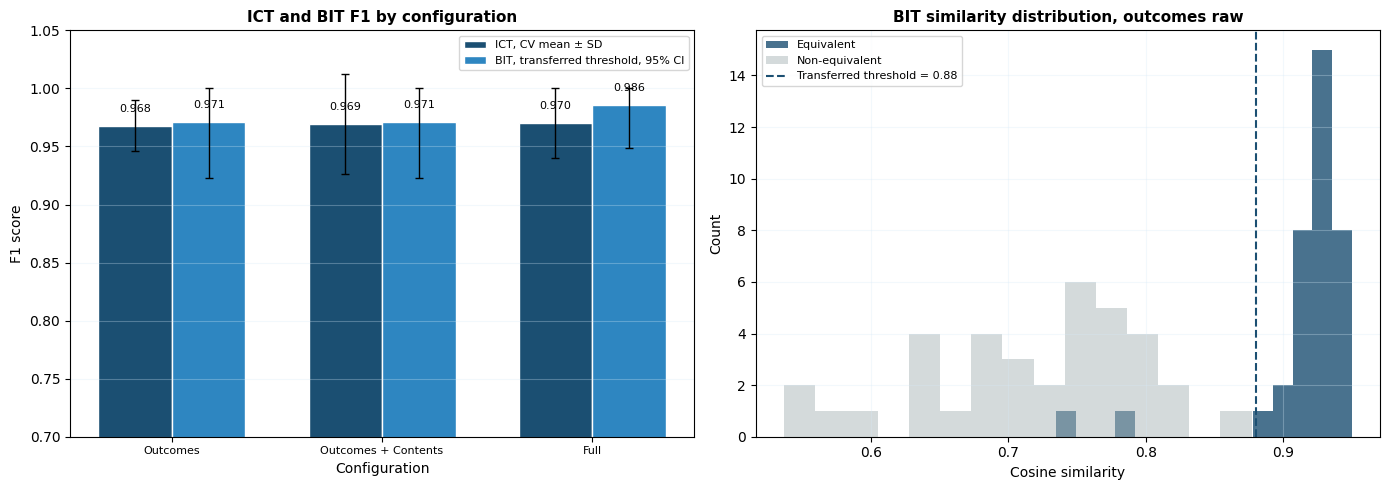

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\bit_generalisation.png


In [15]:
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]

cfg_labels = ['Outcomes', 'Outcomes + Contents', 'Full']

ict_means = combined_df['ict_f1_cv_mean'].values
ict_stds  = combined_df['ict_f1_cv_std'].values
bit_means = combined_df['bit_f1_full_at_transferred'].values
bit_lo    = combined_df['bit_f1_full_ci_low'].values
bit_hi    = combined_df['bit_f1_full_ci_high'].values

x = np.arange(3)
width = 0.35

ax1.bar(
    x - width / 2,
    ict_means,
    width,
    yerr=ict_stds,
    label='ICT, CV mean ± SD',
    color=PRIMARY,
    edgecolor='white',
    error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 1}
)

ax1.bar(
    x + width / 2,
    bit_means,
    width,
    yerr=[bit_means - bit_lo, bit_hi - bit_means],
    label='BIT, transferred threshold, 95% CI',
    color=SECONDARY,
    edgecolor='white',
    error_kw={'ecolor': 'black', 'capsize': 3, 'linewidth': 1}
)

for i, v in enumerate(ict_means):
    ax1.text(i - width / 2, v + 0.012, f'{v:.3f}', ha='center', fontsize=8)

for i, v in enumerate(bit_means):
    ax1.text(i + width / 2, v + 0.012, f'{v:.3f}', ha='center', fontsize=8)

ax1.set_title('ICT and BIT F1 by configuration', fontsize=11, fontweight='bold')
ax1.set_xlabel('Configuration')
ax1.set_ylabel('F1 score')
ax1.set_xticks(x)
ax1.set_xticklabels(cfg_labels, fontsize=8)
ax1.legend(fontsize=8)
ax1.set_ylim(0.70, 1.05)
ax1.grid(axis='y', alpha=0.3, color=GRID_COLOR)

ax2 = axes[1]

fi1, en1 = bit_embeddings[1]
sim1 = np.sum(fi1 * en1, axis=1)
t1 = ict_reference[1]['transfer_threshold']

ax2.hist(
    sim1[bit_labels == 1],
    bins=15,
    alpha=0.8,
    color=POSITIVE,
    label='Equivalent'
)

ax2.hist(
    sim1[bit_labels == 0],
    bins=15,
    alpha=0.5,
    color=NEGATIVE,
    label='Non-equivalent'
)

ax2.axvline(
    x=t1,
    color=PRIMARY,
    linestyle='--',
    linewidth=1.5,
    label=f'Transferred threshold = {t1:.2f}'
)

ax2.set_title('BIT similarity distribution, outcomes raw', fontsize=11, fontweight='bold')
ax2.set_xlabel('Cosine similarity')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, color=GRID_COLOR)

plt.tight_layout()

plot_path = FIGURES_DIR / 'bit_generalisation.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved: {plot_path}")

### Notebook Summary

This notebook tested the generalisation of LaBSE to a completely independent dataset from JAMK's Business Information Technology (BIT) degree programme. The evaluation separated model-generalisation from threshold-transfer, reporting both explicitly and using configuration-specific thresholds to keep the transfer test fair.

At each configuration's matched ICT-calibrated threshold applied zero-shot, LaBSE achieves the BIT F1 values shown in Part A with bootstrap 95 percent confidence intervals. At the BIT-optimal threshold estimated honestly through 5-fold cross-validation on BIT, LaBSE achieves the values shown in Part B. The combined view isolates the cost of the threshold transfer in the `threshold_gap` column and the cost of the domain shift in the `ict_to_bit_f1_gap` column.

The similarity score distribution on BIT shows the same clean separation between equivalent and non-equivalent pairs observed on ICT, supporting the reading that LaBSE's cross-lingual representation transfers across these two Finnish-English curriculum domains. This outcome is consistent with the cross-domain behaviour reported by Reimers and Gurevych (2020) for multilingual distilled models, and with the translation-ranking objective of LaBSE described by Feng et al. (2022), which was designed explicitly to produce language-agnostic sentence representations that hold across diverse text domains.

### Validation Design Limitations

Five limitations apply specifically to this generalisation test and should be carried into the discussion chapter of the thesis.

**Same institution.** Both ICT and BIT datasets originate from JAMK. Transfer to other Finnish universities of applied sciences, let alone research universities, is not tested here. Institutions with different terminology, course-description conventions, and curriculum structures may produce different transfer behaviour.

**Same data schema.** Both datasets were extracted from the same JAMK Peppi curriculum management system and follow the same field structure (outcomes, contents, assessment). Systems using different field names, different granularity, or different typical text lengths are outside the tested scope.

**Technology-adjacent domains.** ICT and BIT are both technology-oriented degree programmes. The domain gap between them is narrower than it would be between, say, ICT and Nursing or Social Services. A stronger domain-shift test would pair technology-side data with humanities-side or health-sciences data.

**Small external validation set.** The BIT dataset is limited in size, and the 5-fold held-out folds in Part B are correspondingly small. Bootstrap CIs in Part A and fold standard deviations in Part B both quantify this, but it means observed differences of a few F1 points should be read with the intervals in mind.

**Possible truncation differences.** The BIT truncation profile reported at the start of this notebook should be compared against the ICT truncation profile from Notebook 2. If BIT texts truncate at a substantially different rate, a portion of any Config 2 or Config 3 F1 difference may reflect truncation rather than domain shift. The Config 1 (outcomes-only) result is unaffected by this caveat because truncation is zero in that configuration on both datasets.